# Image denoising (part II)

The objective of this exercise is implementing several advanced image denoising techniques

## Anisotropic diffusion

In diffusion approaches, a finite difference scheme is used to remove the noise.

Given the following structure:

1. Implement the linear diffusion approach.

2. Implement the Perona-Malik diffusion technique.
    
 2.1. Consider the two diffusivity functions proposed in the paper (see Eqs. 16 and 17 in Lecture 2).
 
 2.2. Implement a third diffusion approach using regularized gradients in diffusivity (see Eqs. 26 and 27 in Lecture 2).


3. Show how the number of iterations and the parameter lambda (in the case of the anisotropic diffusion) affect the results.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
from skimage.util import random_noise
from skimage import data

import cv2
import numpy as np
from sklearn.metrics import mean_absolute_error

%matplotlib inline

plt.rcParams['figure.figsize'] = [16,8]


In [2]:
def linear_step(im, **kwargs):
    
    im = cv2.Laplacian(im, ddepth=-1, ksize=1)
    return im
    
    
def anisotropic_step_g1(im, **kwargs):
    ux = cv2.Sobel(im, ddepth=-1, dx=1, dy=0, ksize=3)
    uy = cv2.Sobel(im, ddepth=-1, dx=0, dy=1, ksize=3)
    
    # Magnitude
    s = np.square(ux**2 + uy**2)
    
    # Gradient Magnitude
    g = 1/(1 + (s**2/kwargs['lmbda']**2))
    
    ## función roll numpy
    
    gu_ux = cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [0, 1/2, 0],
                                            [0, 1/2, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [0, -1, 0],
                                                                                                [0, 1, 0]])) \
         - cv2.filter2D(g, -1, kernel = np.array([[0, 1/2, 0],
                                            [0, 1/2, 0],
                                            [0, 0, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, -1, 0],
                                                                                                [0, 1, 0],
                                                                                                [0, 0, 0]]))
        
    gu_uy = cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [0, 1/2, 1/2],
                                            [0, 0, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [0, -1, 1],
                                                                                                [0, 0, 0]])) \
         - cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [1/2, 1/2, 0],
                                            [0, 0, 0]]))  * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [-1, 1, 0],
                                                                                                [0, 0, 0]]))
    
    im = (gu_ux + gu_uy) 
    return im

def anisotropic_step_g2(im, **kwargs):

    ux = cv2.Sobel(im, ddepth=-1, dx=1, dy=0, ksize=3)
    uy = cv2.Sobel(im, ddepth=-1, dx=0, dy=1, ksize=3)
    
    # Magnitude
    s = np.square(ux**2 + uy**2)
    
    # Gradient Magnitude
    g = np.exp(-(s**2/kwargs['lmbda']**2))
    
    gu_ux = cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [0, 1/2, 0],
                                            [0, 1/2, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [0, -1, 0],
                                                                                                [0, 1, 0]])) \
         - cv2.filter2D(g, -1, kernel = np.array([[0, 1/2, 0],
                                            [0, 1/2, 0],
                                            [0, 0, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, -1, 0],
                                                                                                [0, 1, 0],
                                                                                                [0, 0, 0]]))
        
    gu_uy = cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [0, 1/2, 1/2],
                                            [0, 0, 0]])) * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [0, -1, 1],
                                                                                                [0, 0, 0]])) \
         - cv2.filter2D(g, -1, kernel = np.array([[0, 0, 0],
                                            [1/2, 1/2, 0],
                                            [0, 0, 0]]))  * cv2.filter2D(im, -1, kernel = np.array([[0, 0, 0],
                                                                                                [-1, 1, 0],
                                                                                                [0, 0, 0]]))
    im = (gu_ux + gu_uy) 
    return im

def regularized_anisotropic_step(im, **kwargs):
    u_sigma = cv2.GaussianBlur(im, (3,3), kwargs['sigma']) * im
    return anisotropic_step_g1(u_sigma, lmbda = kwargs['lmbda'])

def diffusion(im, iterations, func, t, **kwargs):
    
    u_t = np.copy(im)
    for i in range(iterations):
        u_t = u_t + t * func(u_t, **kwargs)       
    return u_t
        


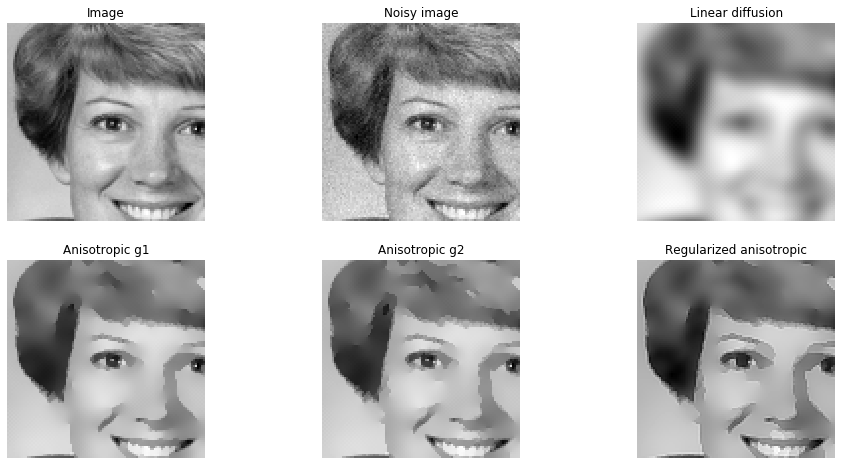

In [3]:
## Iterations = 250 and lmbda = 80
im = data.astronaut()[:,:,1].astype(np.float32)/255
noisy = random_noise(im, var=0.001)

iterations = 25
t = 0.25
linear_result = diffusion(noisy,iterations, linear_step, t)
ad1_result = diffusion(noisy, iterations, anisotropic_step_g1, t, lmbda=0.01)
ad2_result = diffusion(noisy, iterations, anisotropic_step_g2, t, lmbda=0.01)
ad3_result = diffusion(noisy, iterations, regularized_anisotropic_step, t, lmbda=0.01, sigma= 1)


fig, ax = plt.subplots(2,3)
titles = [['Image', 'Noisy image', 'Linear diffusion'], ['Anisotropic g1', 'Anisotropic g2', 'Regularized anisotropic']]
images = [[im, noisy, linear_result], [ad1_result, ad2_result, ad3_result]]
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].axis('off')
        ax[i,j].title.set_text(titles[i][j])
        ax[i,j].imshow(images[i][j][50:150,150:250], cmap='gray')
plt.show()

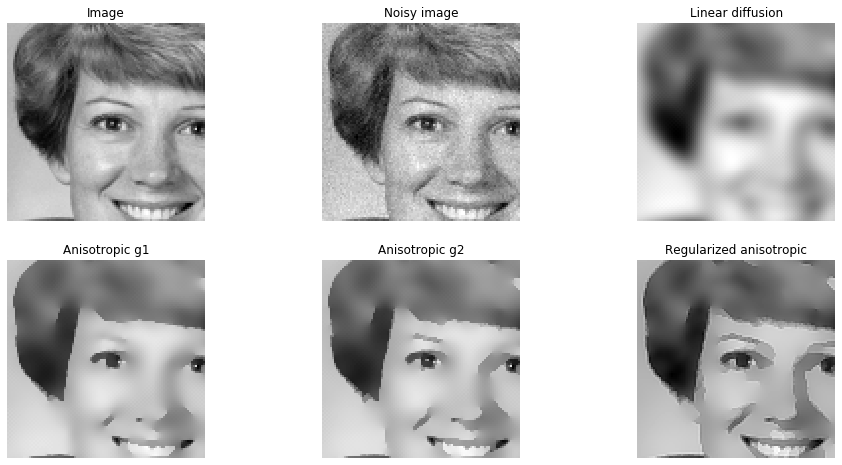

In [4]:
## Iterations = 25 and lmbda = 0.05

iterations = 25
t = 0.25
linear_result = diffusion(noisy,iterations, linear_step, t)
ad1_result = diffusion(noisy, iterations, anisotropic_step_g1, t, lmbda=0.05)
ad2_result = diffusion(noisy, iterations, anisotropic_step_g2, t, lmbda=0.05)
ad3_result = diffusion(noisy, iterations, regularized_anisotropic_step, t, lmbda=0.01, sigma= 1)


fig, ax = plt.subplots(2,3)
titles = [['Image', 'Noisy image', 'Linear diffusion'], ['Anisotropic g1', 'Anisotropic g2', 'Regularized anisotropic']]
images = [[im, noisy, linear_result], [ad1_result, ad2_result, ad3_result]]
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].axis('off')
        ax[i,j].title.set_text(titles[i][j])
        ax[i,j].imshow(images[i][j][50:150,150:250], cmap='gray')
plt.show()

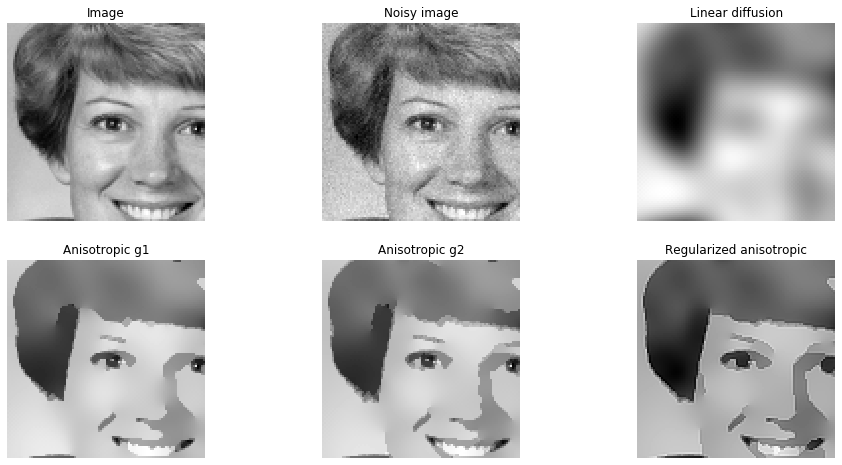

In [5]:
## Iterations = 50 and lmbda = 0.01

iterations = 100
t = 0.25
linear_result = diffusion(noisy,iterations, linear_step, t)
ad1_result = diffusion(noisy, iterations, anisotropic_step_g1, t, lmbda=0.01)
ad2_result = diffusion(noisy, iterations, anisotropic_step_g2, t, lmbda=0.01)
ad3_result = diffusion(noisy, iterations, regularized_anisotropic_step, t, lmbda=0.01, sigma= 1)


fig, ax = plt.subplots(2,3)
titles = [['Image', 'Noisy image', 'Linear diffusion'], ['Anisotropic g1', 'Anisotropic g2', 'Regularized anisotropic']]
images = [[im, noisy, linear_result], [ad1_result, ad2_result, ad3_result]]
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].axis('off')
        ax[i,j].title.set_text(titles[i][j])
        ax[i,j].imshow(images[i][j][50:150,150:250], cmap='gray')
plt.show()

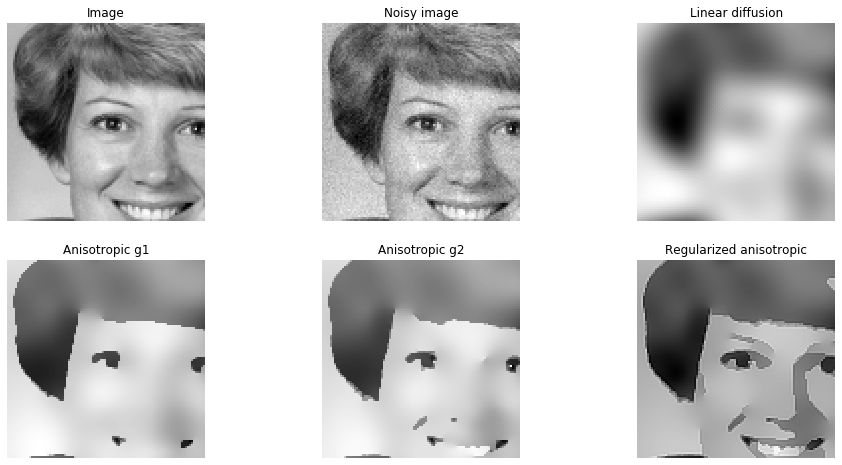

In [6]:
## Iterations = 50 and lmbda = 0.05

iterations = 100
t = 0.25
linear_result = diffusion(noisy,iterations, linear_step, t)
ad1_result = diffusion(noisy, iterations, anisotropic_step_g1, t, lmbda=0.05)
ad2_result = diffusion(noisy, iterations, anisotropic_step_g2, t, lmbda=0.05)
ad3_result = diffusion(noisy, iterations, regularized_anisotropic_step, t, lmbda=0.01, sigma= 1)


fig, ax = plt.subplots(2,3)
titles = [['Image', 'Noisy image', 'Linear diffusion'], ['Anisotropic g1', 'Anisotropic g2', 'Regularized anisotropic']]
images = [[im, noisy, linear_result], [ad1_result, ad2_result, ad3_result]]
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        ax[i,j].axis('off')
        ax[i,j].title.set_text(titles[i][j])
        ax[i,j].imshow(images[i][j][50:150,150:250], cmap='gray')
plt.show()